In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np



In [ ]:
file_path = '/content/drive/MyDrive/Scrapped Articles/transactions.csv'

df = pd.read_csv(file_path)

# Look at the first few rows
df1 = df.loc[df['Class'] == 1]
df2=df.loc[df['Class'] == 0]

df1.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1


In [ ]:
print(df2.shape)
print(df1.shape)

(284315, 31)
(492, 31)


/tmp/ipykernel_25682/32428070.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Amount']/=100
/tmp/ipykernel_25682/32428070.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Amount']/=100


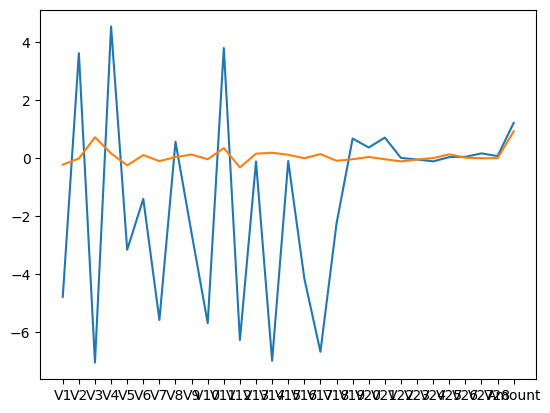

In [ ]:
import matplotlib.pyplot as plt
df1['Amount']/=100
df1_=df1.drop(columns=['Time', 'Class'])
x1=df1_.columns
y1=df1_.mean().values

df2['Amount']/=100
df2=df2.drop(columns=['Time', 'Class'])
y2=df2[:50000].mean().values
plt.plot(x1, y1, label="1")
plt.plot(x1, y2, label="0")



In [ ]:
#227,451  394 Train-distribution
#56,864  98  Test-distribution

from sklearn.model_selection import train_test_split
y=df['Class']
x1=df.drop(columns=['Time', 'Class'])
x1["Amount"]/=100
x=x1.values
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, stratify=y,random_state=4)




In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=100)
log_reg.fit(x_train, y_train)


LogisticRegression()

In [ ]:
y_pred=log_reg.predict(x_test)
from sklearn import metrics
from sklearn.metrics import confusion_matrix, precision_score, recall_score,classification_report
print("Classification_report:", classification_report(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
c_m=confusion_matrix(y_test, y_pred)
print(c_m)
print("LOSS :",c_m[0,1]+c_m[1,0]*25)

#       Confusion Matrix
# True Negative    False Positive
# False Negative   True Positive
# As we see using logistic regression we were able to identify 70 out of the total 98 cases earning a recall of 0.71
# Which is decent but not yet satisfactary......, Our Loss is still high at 710 ,f1_score=0.79
# As the loss function heavily penalizes missed fradulent cases , our main focus would be to increase recall

Classification_report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.71      0.79        98

    accuracy                           1.00     56962
   macro avg       0.94      0.86      0.89     56962
weighted avg       1.00      1.00      1.00     56962

Precision: 0.875
Recall: 0.7142857142857143
[[56854    10]
 [   28    70]]
LOSS : 710


That was the base model , now to apply some class imbalance techniques

In [123]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve

In [ ]:
from sklearn.metrics import make_scorer
def custom_cost(y_true, y_pred):

    c_m = confusion_matrix(y_true,y_pred)

    score = -(c_m[0,1]+c_m[1,0]*25)

    return score
custom_scorer = make_scorer(custom_cost)

Logistic Regression

In [124]:
pipe = Pipeline([
    ('under_sample', RandomUnderSampler()),
    ('smote', SMOTE()),
    ('log_reg', LogisticRegression(max_iter=500))
])

param_grid = {

    'under_sample__sampling_strategy': [0.01,0.005],
    'smote__sampling_strategy': [0.05,0.1],
    'smote__k_neighbors': [3,5,7],
    'log_reg__C': [0.001,0.005]

}


grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring=custom_scorer,
    n_jobs=-1
)

grid.fit(x_train, y_train)

print(grid.best_params_)

Tuned_model=grid.best_estimator_

#pipe.fit(x_train, y_train)
y_pred=Tuned_model.predict(x_test)
print(classification_report(y_test, y_pred))
c_m=confusion_matrix(y_test, y_pred)
print(c_m)
print("LOSS :",c_m[0,1]+c_m[1,0]*25)

{'log_reg__C': 0.001, 'smote__k_neighbors': 7, 'smote__sampling_strategy': 0.1, 'under_sample__sampling_strategy': 0.005}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.63      0.84      0.72        98

    accuracy                           1.00     56962
   macro avg       0.81      0.92      0.86     56962
weighted avg       1.00      1.00      1.00     56962

[[56815    49]
 [   16    82]]
LOSS : 449


0.437
445


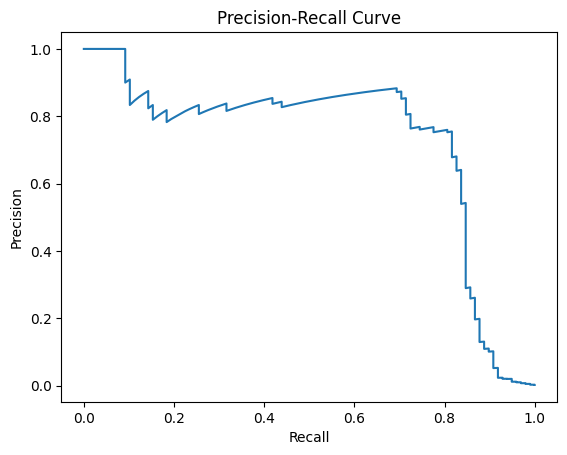

In [125]:
best_threshold = 0
least_loss = 100000
y_prob=Tuned_model.predict_proba(x_test)[:,1]


for t in [i/1000 for i in range(1,1000)]:

    y_pred1 = (y_prob > t).astype(int)

    loss = -custom_cost(y_test, y_pred1)

    if least_loss > loss :
        least_loss = loss
        best_threshold = t

print(best_threshold)
print(least_loss)
# It seems we could reduce the loss a little further by tuning the threshold to 0.438 instead of 0.5

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
# After optimization using imbalanced class techniques like oversampling(smote),undersampling,and optimising
# with respect to our loss function(This was really necessary to tell our model that this is actually what we want not just accuracy),by
# doing this we are able to reduce our loss by 30% ,giving us loss = 452(or 444) comapred to 710 before,
# we also see a sacrifice of precision for recall , in order for the model to match the heavy penalization of false negative (missed fraud)
# lets see if using other models can help improve this further.
# From here on out i'll be using imbalance techniques since there is clear advantage of using them

Random Forest

In [121]:
pipe1 = Pipeline([
    ('under_sample', RandomUnderSampler(sampling_strategy=0.05)),
    ('smote', SMOTE(sampling_strategy=0.1)),
    ('RFC', RandomForestClassifier(min_samples_split=4,n_estimators=100,max_depth=20))
])

'''


param_grid = {

        'under_sample__sampling_strategy': [0.05,0.01,0.05],
        'smote__sampling_strategy': [0.01,0.05,0.1],
        'smote__k_neighbors': [3,5],
        "RFC__n_estimators": [100, 200],
        "RFC__max_depth": [None, 10, 20],
        "RFC__min_samples_split": [2, 5],
}


grid = GridSearchCV(
    pipe1,
    param_grid,
    cv=5,
    scoring=custom_scorer,
    n_jobs=-1
)
grid.fit(x_train, y_train)

print(grid.best_params_)

Tuned_model=grid.best_estimator_
'''

# Here RFC takes much more time to train and hence I found the optimum values from grid and entered it into the original pipeline
# to avoid running this time-consuming task everytime


pipe1.fit(x_train, y_train)
y_pred=pipe1.predict(x_test)
print(classification_report(y_test, y_pred))
c_m=confusion_matrix(y_test, y_pred)
print(c_m)
print("LOSS :",c_m[0,1]+c_m[1,0]*25)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.63      0.84      0.72        98

    accuracy                           1.00     56962
   macro avg       0.81      0.92      0.86     56962
weighted avg       1.00      1.00      1.00     56962

[[56815    49]
 [   16    82]]
LOSS : 449


0.462
431


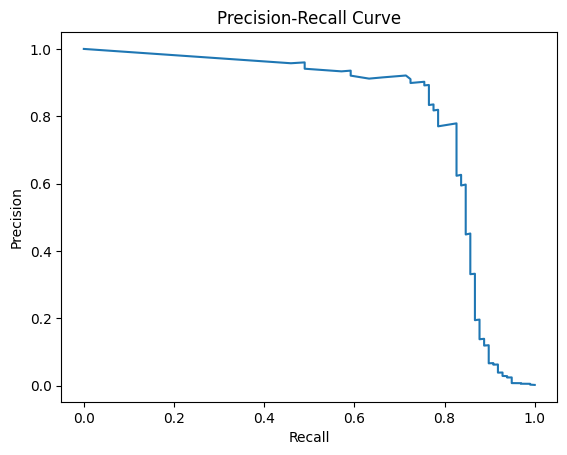

In [126]:
best_threshold = 0
least_loss = 100000
y_prob=pipe1.predict_proba(x_test)[:,1]


for t in [i/1000 for i in range(1,1000)]:

    y_pred1 = (y_prob > t).astype(int)

    loss = -custom_cost(y_test, y_pred1)

    if least_loss > loss :
        least_loss = loss
        best_threshold = t

print(best_threshold)
print(least_loss)
# It seems we could reduce the loss a little further by tuning the threshold to 0.53 but the lose drop is not that significant

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

Boosted Trees

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier


In [128]:

pipe2 = Pipeline([
    ('under_sample', RandomUnderSampler(sampling_strategy=0.01)),
    ('smote', SMOTE(sampling_strategy=0.05)),
    ('XGBC',XGBClassifier(n_estimators=400,max_depth=6,subsample=0.8,scale_pos_weight=1,learning_rate=0.05))
])
'''
    'under_sample__sampling_strategy': [0.05,0.01,0.05],
    'smote__sampling_strategy': [0.01,0.05,0.1],
    'smote__k_neighbors': [3,5],
    "XGBC__learning_rate": [0.05, 0.1],
    "XGBC__max_depth": [4, 6],
    "XGBC__subsample": [0.8, 1.0],
    "XGBC__scale_pos_weight": [10, 25, 50]
    "XGBC__n_estimators": [300, 400,500],

param_grid = {
    "XGBC__n_estimators": [300, 400,500],

}

grid = GridSearchCV(
    pipe2,
    param_grid,
    cv=5,
    scoring=custom_scorer,
    n_jobs=-1
)
'''

#Similar to the last one it takes too much time to compute hence I did them in shorter pairs across multiple files and then
# took the computed value and added it to the initial pipeline



#print(pipe.best_params_)


pipe2.fit(x_train, y_train)

y_pred=pipe2.predict(x_test)
print(classification_report(y_test, y_pred))
c_m=confusion_matrix(y_test, y_pred)
print(c_m)
print("LOSS :",c_m[0,1]+c_m[1,0]*25)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.76      0.84      0.80        98

    accuracy                           1.00     56962
   macro avg       0.88      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962

[[56838    26]
 [   16    82]]
LOSS : 426


0.66
417


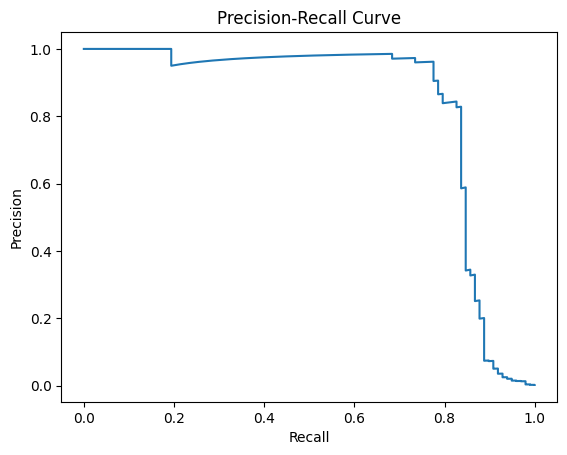

In [129]:
best_threshold = 0
least_loss = 100000
y_prob=pipe2.predict_proba(x_test)[:,1]


for t in [i/100 for i in range(1,100)]:

    y_pred1 = (y_prob > t).astype(int)

    loss = -custom_cost(y_test, y_pred1)

    if least_loss > loss :
        least_loss = loss
        best_threshold = t

print(best_threshold)
print(least_loss)
# It seems we could reduce the loss a little further by tuning the threshold to 0.58 but the lose drop is again almost negligable

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

Analysis

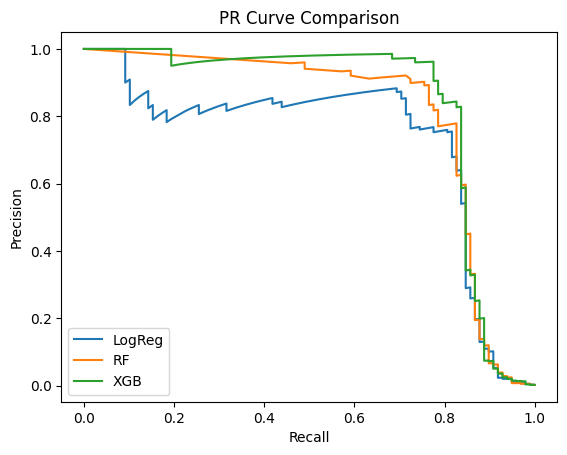

In [130]:

models={
    "LogReg": Tuned_model,
    "RF": pipe1,
    "XGB": pipe2
}

for name, model in models.items():

    y_scores = model.predict_proba(x_test)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_scores
    )

    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve Comparison")

plt.legend()
plt.show()
# In general we know that the goal is to maximize both precision and recall, though here recall is prefered due to the unsymetric cost 1:25
# ON comparing in the graph we can see that in general XGB outperforms the other models,while logistic lags behind

In [131]:
# Confusion Matices
for name, model in models.items():
  print(name)
  print(confusion_matrix(y_test, model.predict(x_test)),"\n\n")

# Though every instance has some randomization in the results such as here RF performs the same as log (though it is usually slightly better)
# it is generally seen that the models try to minimize their loss in FN , till a level after which they don't improve and
# then aim to reduce their FP

LogReg
[[56815    49]
 [   16    82]] 


RF
[[56815    49]
 [   16    82]] 


XGB
[[56838    26]
 [   16    82]] 




In [132]:
!pip install shap

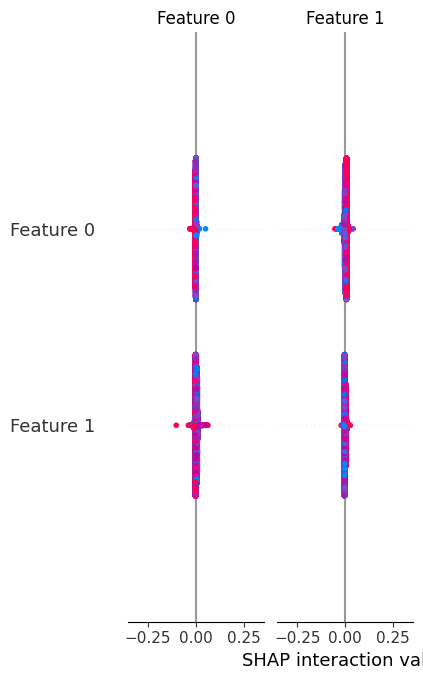

In [137]:
import shap
explainer = shap.TreeExplainer(pipe1.named_steps["RFC"])
shap_values = explainer.shap_values(x_test)
shap.summary_plot(shap_values, x_test)